# Description:

This notebook provides a collection of analysis functions for multicomponent glass structures based on LAMMPS dump files.
It supports structural characterization using atomic-level information based on the features described below.

## Available Analyses:

- Coordination Numbers: Computes how many neighbors each atom has within a cutoff.
- Bridging and Non-Bridging Oxygens: Determines network connectivity through oxygen coordination.
- Qn Distribution: Counts the number of bridging oxygens attached to each former (e.g., Si), yielding Qn statistics.
- Bond Angle Distribution: Calculates the angles between triplets of atoms to assess structural order.
- Network Connectivity: Computes average Qⁿ value across the system.


## Input Requirements:
Currently, all functions assume LAMMPS dump file format (optionally gzipped). The simulation cell needs to be cubic or orthorhombic.
The required fields in the dump file are: atom ID, type, coordinates (wrapped or unwrapped), and box dimensions.

## Main Functions:

- `read_lammps_dump()`: Read atom data and box size.
- `remove_atom_type()`: Remove unwanted atom types.
- `compute_cell_list()`, `get_neighbors()`: neighbor search using a cell list.
- `compute_coordination()`: Coordination histogram for a given atom type.
- `compute_Qn()`: Compute Qⁿ and partial Qⁿ distributions.
- `compute_network_connectivity()`: Calculate the average Qⁿ.
- `compute_angles()`: Compute bond angle distributions (partial implementation).
- `write_distribution_to_file()`: Output histogram data to file.



In [2]:
import matplotlib.pyplot as plt
import os
import sys  

# Be able to import the pyiron_glass package if workdir is in the notebooks folder and if 
# global PYTHONPATH variable is not set to the pyiron_glass folder.
print(os.getcwd())
if os.getcwd().endswith("notebooks") and os.getcwd()+"/../pyiron_glass/src/" not in sys.path:
    sys.path.append(os.getcwd()+"/../pyiron_glass/src/")

from pyiron_glass import (
    read_lammps_dump,
    compute_coordination,
    compute_Qn,
    compute_network_connectivity,
    write_distribution_to_file,
    compute_angles,
)

/pl_l33/msa/work/pyiron-glasagent/pyiron-glass/notebooks


In [3]:
filename = "data/SiONa_25.dump.gz"
cutoff_map = { # Cutoff distances for different atom types
    'O': 2.0,
    'Si': 2.0,
    'Na': 3.0,
}
# Atom type mapping (as per LAMMPS input)
type_map = {
    1: 'O',
    2: 'Si',
    3: 'Na',
}

network_formers = {'Si'}#, 'B', 'Al'}
modifiers = {'Na'}#, 'Ca'}
O_type = [t for t, e in type_map.items() if e == 'O']
former_types = [t for t, e in type_map.items() if e in network_formers]
modifier_types = [t for t, e in type_map.items() if e in modifiers]


ids, types, coords, box_size = read_lammps_dump(filename, unwrap=False)

# Coordination distributions
O_coord, _ = compute_coordination(ids, types, coords, box_size, O_type, cutoff_map['O'], former_types)

former_coords = {type_map[t]: compute_coordination(ids, types, coords, box_size, [t], cutoff_map[type_map[t]], O_type)[0] for t in former_types}

modifier_coords = {type_map[t]: compute_coordination(ids, types, coords, box_size, [t], cutoff_map[type_map[t]], O_type)[0] for t in modifier_types}

Qn_dist, _ = compute_Qn(ids, types, coords, box_size, cutoff_map['O'], former_types, O_type)

# Print results
print("\nO_n distribution:")

for n, c in O_coord.items():
    print(f"O_{n}: {c}")

for former, coord in former_coords.items():
    print(f"\n{former}_n distribution:")
    for n, c in coord.items():
        print(f"{former}_{n}: {c}")

for mod, coord in modifier_coords.items():
    print(f"\n{mod}_n distribution:")
    for n, c in coord.items():
        print(f"{mod}_{n}: {c}")

print("\nQn distribution:")
for n, c in sorted(Qn_dist.items()):
    print(f"Q_{n}: {c}")

total_formers = sum(len(v) for v in former_coords.values())
net_conn = compute_network_connectivity(Qn_dist)
print(f"\nNetwork connectivity: {net_conn:.4f}")


x = 45
# Write O_n distribution
write_distribution_to_file(x, "O_n.dat", O_coord, "O")

# Write each former type distribution
for former, coord in former_coords.items():
    write_distribution_to_file(x, f"{former}_n.dat", coord, former)

# Write each modifier type distribution
for mod, coord in modifier_coords.items():
    write_distribution_to_file(x, f"{mod}_n.dat", coord, mod)

# Write Qn distribution
write_distribution_to_file(x, "Qn.dat", Qn_dist, "Q")




O_n distribution:
O_1: 1670
O_2: 4175

Si_n distribution:
Si_4: 2505

Na_n distribution:
Na_2: 5
Na_3: 98
Na_4: 489
Na_5: 630
Na_6: 341
Na_7: 90
Na_8: 16
Na_9: 1

Qn distribution:
Q_0: 0
Q_1: 29
Q_2: 267
Q_3: 1049
Q_4: 1160
Q_5: 0
Q_6: 0

Network connectivity: 3.3333


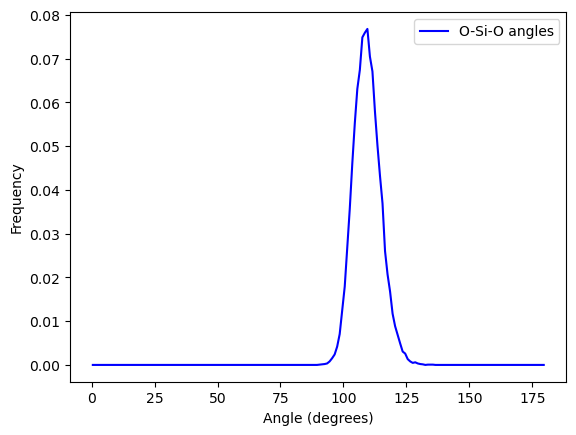

In [4]:
bond_angle_distribution = compute_angles(
    types, 
    coords,
    box_size,
    center_type=[2],
    neighbor_type=[1],  # Assuming Si is the center for O-Si-O angles
    cutoff=2,
    bins=180
)

# Unpack the result to ensure correct usage
angles, counts = bond_angle_distribution

plt.plot(
    angles,
    counts,
    label='O-Si-O angles',
    color='blue',
)
plt.xlabel('Angle (degrees)')
plt.ylabel('Frequency')
plt.legend()
plt.show()